In [1]:
import seaborn as sns
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from formulas import average

# Load the student performance dataset which is clean

df = pd.read_csv('../data/binary_student_perfomance.csv')

In [2]:
df.isna().sum()

gender                  0
age                     0
study_hours_per_week    0
attendance_rate         0
parent_education        0
internet_access         0
extracurricular         0
previous_score          0
final_score             0
passed                  0
dtype: int64

In [3]:
df.head(10)

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed
0,1,15.0,25.0,63.8,2,1,1,41,67,1
1,0,15.0,2.0,54.7,2,1,1,83,28,0
2,0,19.0,10.0,90.5,1,1,0,73,49,0
3,1,16.0,26.0,66.8,1,0,1,75,70,1
4,0,15.0,25.0,73.0,1,0,1,67,77,1
5,0,19.0,8.0,85.2,1,1,0,40,37,0
6,1,18.0,10.0,72.7,3,1,0,75,42,0
7,0,15.0,21.0,81.7,3,1,1,89,70,1
8,0,19.0,9.0,84.2,1,1,1,70,49,0
9,0,15.0,8.0,95.7,3,0,1,93,56,1


In [4]:
# create a column in the frame to get the average score of previous scores and final scores
df['average_score'] = average(df['previous_score'], df['final_score'])
df.head(5)

,gender,age,study_hours_per_week,attendance_rate,parent_education,internet_access,extracurricular,previous_score,final_score,passed,average_score
0,1,15.0,25.0,63.8,2,1,1,41,67,1,54.0
1,0,15.0,2.0,54.7,2,1,1,83,28,0,55.5
2,0,19.0,10.0,90.5,1,1,0,73,49,0,61.0
3,1,16.0,26.0,66.8,1,0,1,75,70,1,72.5
4,0,15.0,25.0,73.0,1,0,1,67,77,1,72.0


### Show distribution of Previous Scores and Final scores by the students


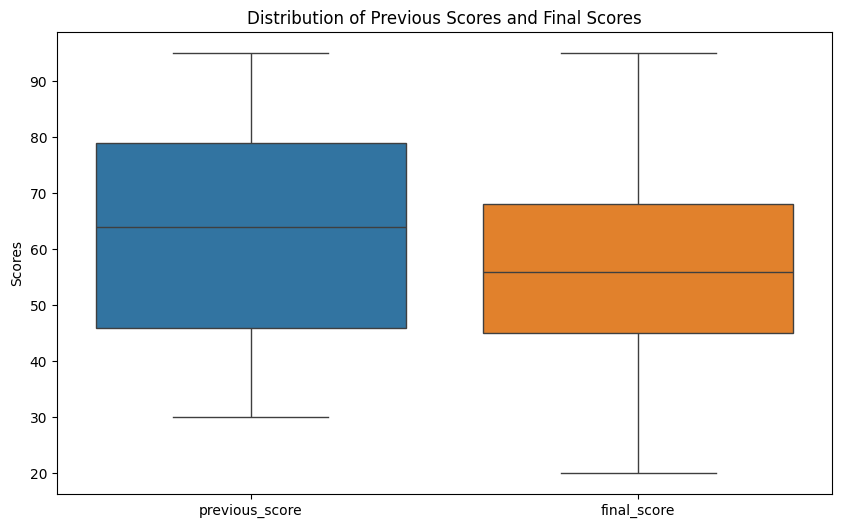

In [5]:
# create box plot to compare the distribution of previous scores and final scores
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[['previous_score', 'final_score']])
plt.title('Distribution of Previous Scores and Final Scores')
plt.ylabel('Scores')
plt.show()

##### The plot above shows:

1. Most students passed at the first exam compared to the last exam.
2. In the previous_score the average score is between 60 to 70.
3. In the final_score the average score is between 50 to 60.
4. In the previous_score the highest score is above 90 and lowest score is 30
5. In the final_score the highest score is above 90 and the lowest score is 20


### Create a heat map

- To spot pattern in the previous score and final score
- To spot pattern with study hours and previous score and final score


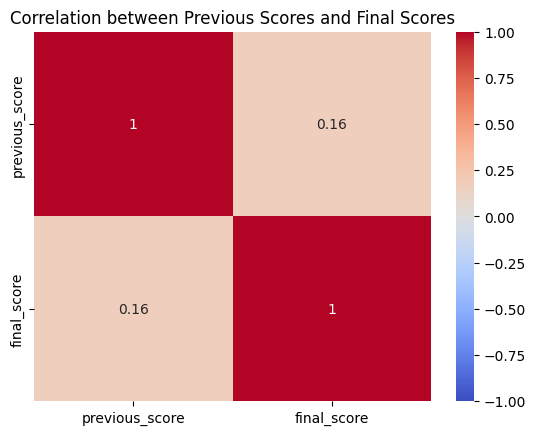

In [6]:
# creat heat map to show the correlation between previous scores and final scores
correlation_matrix = df[['previous_score', 'final_score']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation between Previous Scores and Final Scores')
plt.show()

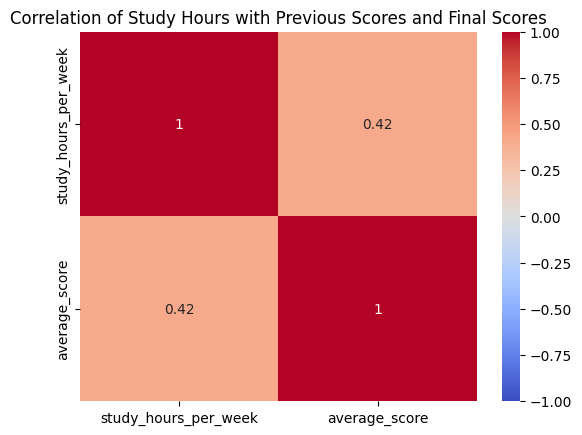

In [7]:
# create heat map to show correlation of study hours with previous scores and final scores
correlation_matrix_study_hours_with_scores = df[[
    'study_hours_per_week', 'average_score']].corr()
sns.heatmap(correlation_matrix_study_hours_with_scores,
            annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation of Study Hours with Previous Scores and Final Scores')
plt.show()

In [8]:
df.dtypes

gender                    int64
age                     float64
study_hours_per_week    float64
attendance_rate         float64
parent_education          int64
internet_access           int64
extracurricular           int64
previous_score            int64
final_score               int64
passed                    int64
average_score           float64
dtype: object

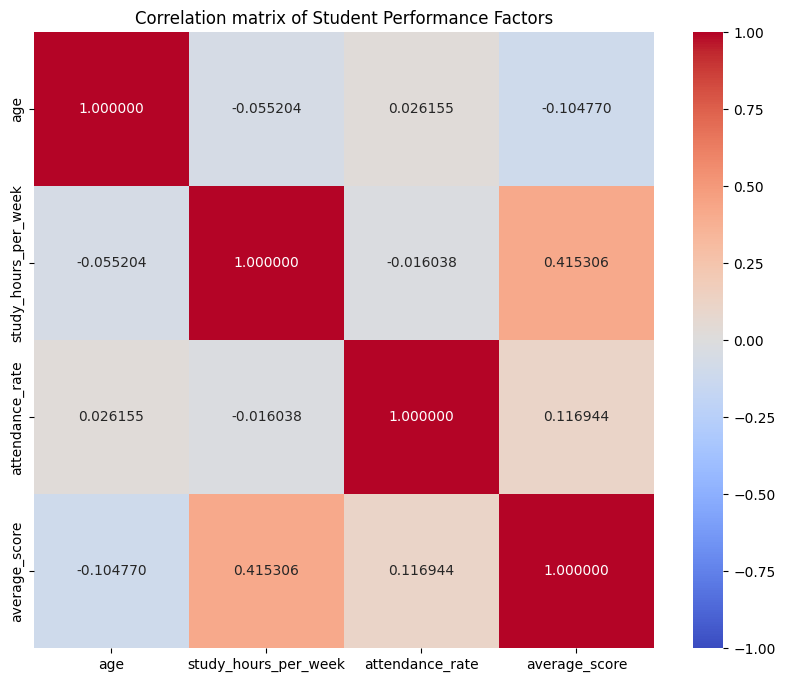

In [9]:
numerical_cols = ['age', 'study_hours_per_week',
                  'attendance_rate', 'average_score']
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',
            fmt="2f", vmin=-1, vmax=1)
plt.title('Correlation matrix of Student Performance Factors')
plt.show()

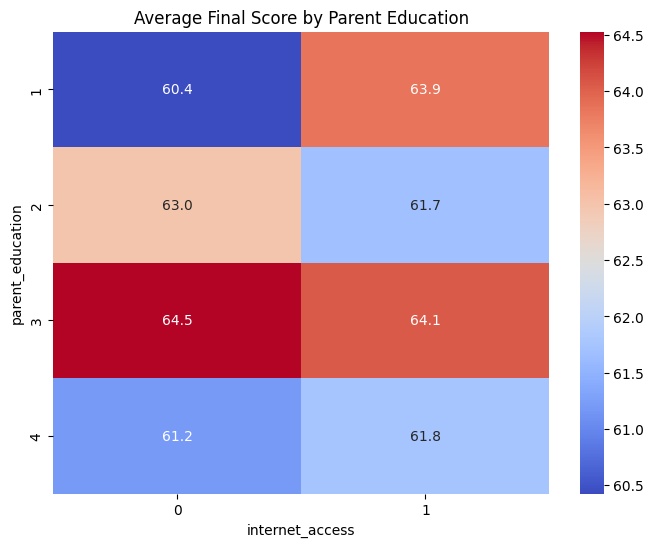

In [10]:
# pivot data to calculate the mean final
pivot_df = df.pivot_table(values='previous_score', index='parent_education',
                          columns='internet_access', aggfunc='mean')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_df, annot=True, cmap='coolwarm', fmt=".1f")
plt.title('Average Final Score by Parent Education')
plt.show()

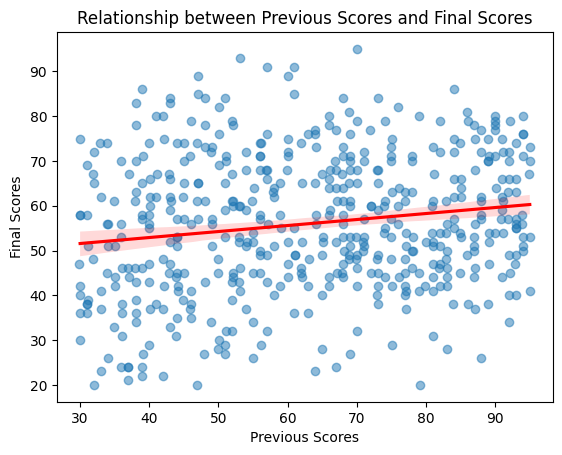

In [11]:
# plot a regression plot to show the relationship between previous scores and final scores
sns.regplot(x='previous_score',
            y='final_score',  #set the x and y axis to previous scores and final scores
            data=df, #load data from the dataframe 
            scatter_kws={'alpha':0.5}, #set the transparency of the scatter points
            x_jitter=0.1, #add some jitter to the x-axis to prevent overlapping points
            #order=2, #fit a second-order polynomial regression line to capture any non-linear relationship
            line_kws={'color':'red'}) #set the color of the regression line to red 
plt.title('Relationship between Previous Scores and Final Scores')
plt.xlabel('Previous Scores')
plt.ylabel('Final Scores')
plt.show()

- visualization to show trends of average scores with study hours per week
- calculate R and R2


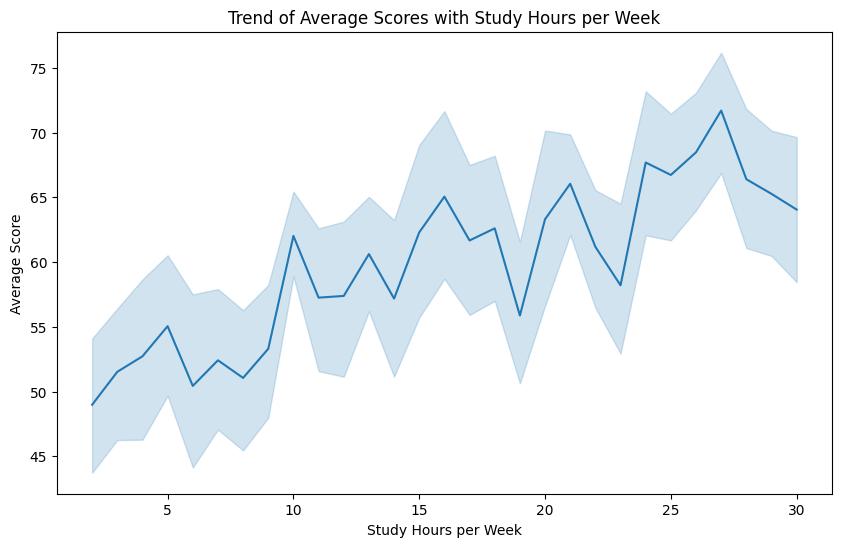

In [12]:
# plot a  line gragh to show the trend of average scores with study hours per week
plt.figure(figsize=(10, 6))
sns.lineplot(x='study_hours_per_week', y='average_score', data=df)
plt.title('Trend of Average Scores with Study Hours per Week')
plt.xlabel('Study Hours per Week')
plt.ylabel('Average Score')
plt.show()

In [13]:
# calculate r and r^2 values for the relationship between study hours per week and average scores
X = df['study_hours_per_week'].values.reshape(-1, 1)  # Reshape for sklearn
y = df['average_score'].values

model = LinearRegression()
model.fit(X, y)
r_squared = model.score(X, y)
r = np.sqrt(r_squared)
print(f"R-squared: {r_squared:.4f}")
print(f"R: {r:.4f}")

R-squared: 0.1725
R: 0.4153


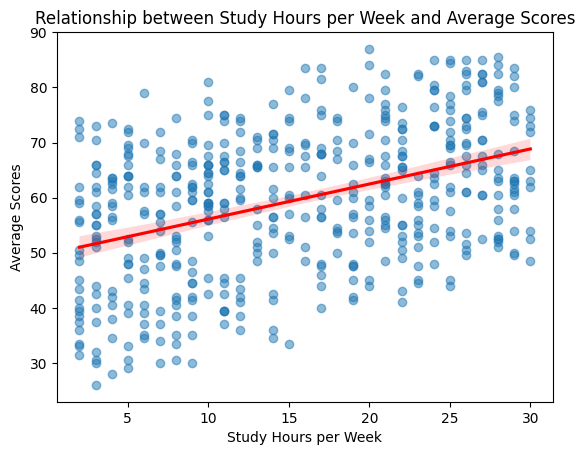

In [43]:
# plot the graph of study hours per week vs average scores with the regression line
sns.regplot(x='study_hours_per_week', y='average_score', data=df,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Relationship between Study Hours per Week and Average Scores')
plt.xlabel('Study Hours per Week')
plt.ylabel('Average Scores')
plt.show()

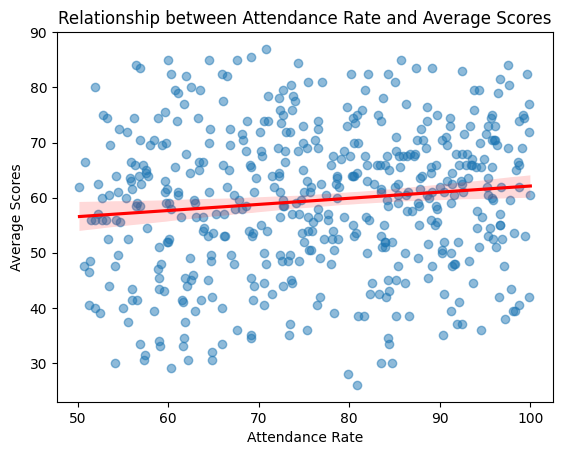

In [44]:
# plot a regression plot to show the relationship between attendance rate and average scores
sns.regplot(x='attendance_rate', y='average_score', data=df,
            scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
plt.title('Relationship between Attendance Rate and Average Scores')
plt.xlabel('Attendance Rate')
plt.ylabel('Average Scores')
plt.show()